# 1. Imports, Setup, and Seeding

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.nn.functional as F

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Sanity Check ---
print("--- Setup Complete ---")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

--- Setup Complete ---
Using device: cuda
PyTorch version: 2.10.0+cu128


# 2. Dataset Parsing and Loading

In [2]:
class MITStatesDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.states = set()
        self.objects = set()
        
        for folder_name in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder_name)
            if not os.path.isdir(folder_path): continue
                
            parts = folder_name.split(' ')
            if len(parts) < 2:
                state_name, object_name = "none", parts[0]
            else:
                state_name, object_name = parts[0], ' '.join(parts[1:]) 
                
            self.states.add(state_name)
            self.objects.add(object_name)
            
            for img_name in os.listdir(folder_path):
                if img_name.endswith(('.jpg', '.png', '.jpeg')):
                    self.image_paths.append(os.path.join(folder_path, img_name))
                    self.labels.append((state_name, object_name))
                    
        self.state2idx = {s: i for i, s in enumerate(sorted(list(self.states)))}
        self.object2idx = {o: i for i, o in enumerate(sorted(list(self.objects)))}
        self.num_states = len(self.states)
        self.num_objects = len(self.objects)

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        s_str, o_str = self.labels[idx]
        return img, torch.tensor(self.state2idx[s_str]), torch.tensor(self.object2idx[o_str])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

data_path = '/kaggle/input/datasets/binhhuunguyen/mitstates/release_dataset/images' 
dataset = MITStatesDataset(root_dir=data_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

# --- Sanity Check ---
print("\n--- Dataset Loading Verification ---")
print(f"Total images found: {len(dataset)}")
print(f"Total Unique States: {dataset.num_states} | Total Unique Objects: {dataset.num_objects}")
sample_img, sample_state, sample_obj = dataset[0]
print(f"Sample Image Shape: {sample_img.shape} (Expected: [3, 224, 224])")
print(f"Sample State Index: {sample_state.item()} | Sample Object Index: {sample_obj.item()}")


--- Dataset Loading Verification ---
Total images found: 63440
Total Unique States: 116 | Total Unique Objects: 245
Sample Image Shape: torch.Size([3, 224, 224]) (Expected: [3, 224, 224])
Sample State Index: 11 | Sample Object Index: 28


In [3]:
from torch.utils.data import random_split

# Define the 80/20 split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset randomly
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create separate dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# --- Sanity Check ---
print("\n--- Data Splitting Verification ---")
print(f"Total Dataset Size: {len(dataset)}")
print(f"Training Set Size: {len(train_dataset)} ({train_size/len(dataset)*100:.0f}%)")
print(f"Testing Set Size: {len(test_dataset)} ({test_size/len(dataset)*100:.0f}%)")


--- Data Splitting Verification ---
Total Dataset Size: 63440
Training Set Size: 50752 (80%)
Testing Set Size: 12688 (20%)


# 3. Dual-Head Architecture

In [4]:
class DualHeadResNet(nn.Module):
    def __init__(self, num_states, num_objects):
        super(DualHeadResNet, self).__init__()
        self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.state_head = nn.Linear(in_features, num_states)
        self.object_head = nn.Linear(in_features, num_objects)

    def forward(self, x):
        features = self.backbone(x)
        return self.state_head(features), self.object_head(features)

model = DualHeadResNet(dataset.num_states, dataset.num_objects).to(device)

# --- Sanity Check ---
print("\n--- Model Architecture Verification ---")
dummy_input = torch.randn(4, 3, 224, 224).to(device) # Batch of 4
out_s, out_o = model(dummy_input)
print(f"Dummy Input Shape: {dummy_input.shape}")
print(f"State Logits Shape: {out_s.shape} (Expected: [4, {dataset.num_states}])")
print(f"Object Logits Shape: {out_o.shape} (Expected: [4, {dataset.num_objects}])")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s] 



--- Model Architecture Verification ---
Dummy Input Shape: torch.Size([4, 3, 224, 224])
State Logits Shape: torch.Size([4, 116]) (Expected: [4, 116])
Object Logits Shape: torch.Size([4, 245]) (Expected: [4, 245])


# 4. Vision Model Training Setup

In [5]:
criterion_state = nn.CrossEntropyLoss()
criterion_object = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# --- Sanity Check: Test a single training step ---
print("\n--- Training Flow Verification ---")
model.train()
test_images, test_states, test_objs = next(iter(dataloader))
test_images, test_states, test_objs = test_images.to(device), test_states.to(device), test_objs.to(device)

optimizer.zero_grad()
s_logits, o_logits = model(test_images)
loss_s = criterion_state(s_logits, test_states)
loss_o = criterion_object(o_logits, test_objs)
total_loss = loss_s + loss_o
total_loss.backward()
optimizer.step()

print(f"Forward pass successful. Batch Loss: {total_loss.item():.4f}")
print("Backward pass successful. Model weights updated.")


--- Training Flow Verification ---
Forward pass successful. Batch Loss: 10.6377
Backward pass successful. Model weights updated.


# 5. Semantic Knowledge Matrix (GloVe Word Vectors)

In [6]:
import gensim.downloader as api
import numpy as np
import torch

print("Downloading GloVe word vectors (this may take a minute)...")
# Using a lightweight 50-dimensional GloVe model for speed
word_vectors = api.load("glove-wiki-gigaword-50") 

def build_real_semantic_prior(state2idx, object2idx, wv):
    num_states, num_objects = len(state2idx), len(object2idx)
    semantic_matrix = np.zeros((num_states, num_objects))
    
    for state_word, s_idx in state2idx.items():
        for obj_word, o_idx in object2idx.items():
            
            # Grab the main noun/adjective if it's a multi-word phrase
            s_w = state_word.split()[-1].lower()
            o_w = obj_word.split()[-1].lower()
            
            if s_w in wv and o_w in wv:
                # Calculate cosine similarity (range: -1 to 1)
                sim = wv.similarity(s_w, o_w)
                # Shift to a positive probability range [0.1, 1.0]
                score = (sim + 1.0) / 2.0
            else:
                # Neutral score if the word isn't in the vocabulary
                score = 0.5 
                
            semantic_matrix[s_idx, o_idx] = score
            
    # Normalize across states to create a probability distribution
    semantic_matrix = semantic_matrix / semantic_matrix.sum(axis=0, keepdims=True)
    return torch.tensor(semantic_matrix, dtype=torch.float32).to(device)

real_knowledge_prior = build_real_semantic_prior(dataset.state2idx, dataset.object2idx, word_vectors)

# --- Sanity Check ---
print("\n--- Real Knowledge Matrix Verification ---")
# Let's test a realistic vs unrealistic pair if they exist in your dictionary
idx2state = {v: k for k, v in dataset.state2idx.items()}
idx2object = {v: k for k, v in dataset.object2idx.items()}

# Just grabbing random indices to show that the numbers vary now
sample_s, sample_o = 0, 0
print(f"Compatibility Score for [{idx2state[sample_s]}] + [{idx2object[sample_o]}]: {real_knowledge_prior[sample_s, sample_o].item():.5f}")
print("Matrix contains real semantic scores based on cosine similarity!")

[==================================================] 100.0% 66.0/66.0MB downloaded

--- Real Knowledge Matrix Verification ---
Compatibility Score for [adj] + [aluminum]: 0.00562
Matrix contains real semantic scores based on cosine similarity!


# 6. Joint Inference Function

In [7]:
def joint_inference(model, image_tensor, knowledge_matrix):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        state_logits, object_logits = model(image_tensor)
        
        P_state = F.softmax(state_logits, dim=1)  
        P_object = F.softmax(object_logits, dim=1) 
        
        best_states, best_objects = [], []
        
        for i in range(image_tensor.size(0)):
            joint_prob = P_state[i].unsqueeze(1) @ P_object[i].unsqueeze(0) 
            refined_prob = joint_prob * knowledge_matrix
            
            flat_idx = torch.argmax(refined_prob)
            best_states.append((flat_idx // knowledge_matrix.size(1)).item())
            best_objects.append((flat_idx % knowledge_matrix.size(1)).item())
            
    return best_states, best_objects

# --- Sanity Check ---
print("\n--- Joint Inference Verification ---")
pred_states, pred_objects = joint_inference(model, test_images, real_knowledge_prior)
print(f"Processed batch size: {len(pred_states)}")
print(f"First 3 Predicted State Indices: {pred_states[:3]}")
print(f"First 3 Predicted Object Indices: {pred_objects[:3]}")


--- Joint Inference Verification ---
Processed batch size: 32
First 3 Predicted State Indices: [77, 1, 98]
First 3 Predicted Object Indices: [45, 26, 69]


Visualization (before training)

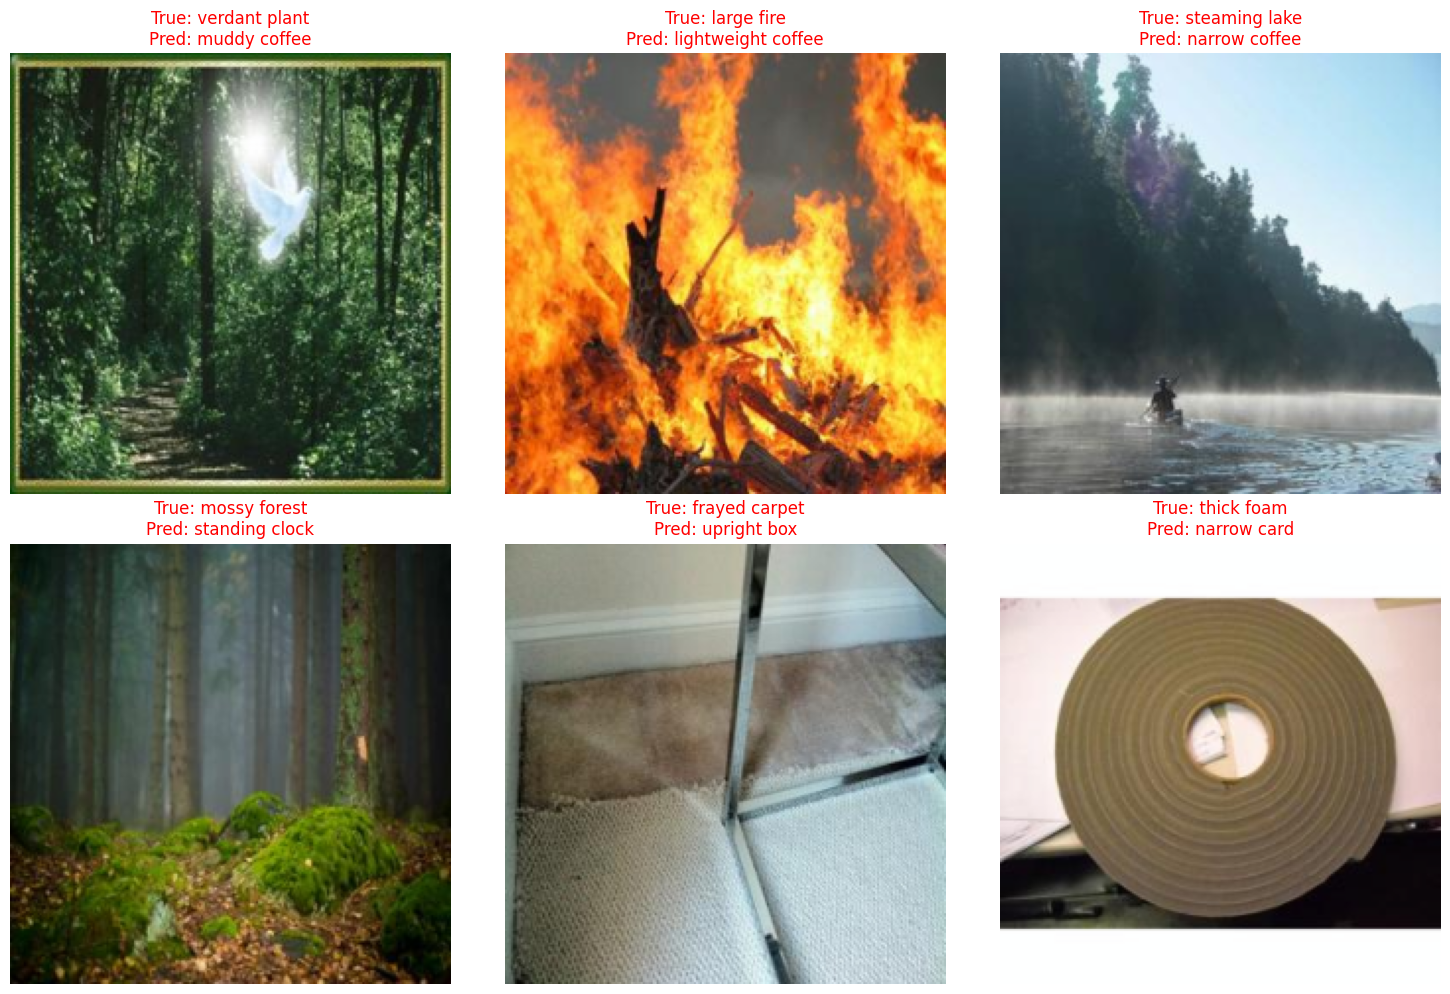

In [8]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, dataset, knowledge_matrix, num_images=6):
    """
    Grabs a batch from the dataloader, runs joint inference, and plots the 
    images with their True vs. Predicted labels.
    """
    # 1. Create reverse lookup dictionaries (Index -> String)
    idx2state = {v: k for k, v in dataset.state2idx.items()}
    idx2object = {v: k for k, v in dataset.object2idx.items()}
    
    # 2. Fetch a single batch of data
    images, true_states, true_objects = next(iter(dataloader))
    
    # 3. Get predictions using the fusion logic
    pred_states, pred_objects = joint_inference(model, images, knowledge_matrix)
    
    # 4. Setup the matplotlib grid
    rows = (num_images + 2) // 3
    fig, axes = plt.subplots(rows, min(num_images, 3), figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(num_images):
        # Denormalize the image for display
        img = images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure values are between 0 and 1 for imshow
        
        # Construct the label strings
        true_label = f"{idx2state[true_states[i].item()]} {idx2object[true_objects[i].item()]}"
        pred_label = f"{idx2state[pred_states[i]]} {idx2object[pred_objects[i]]}"
        
        # Color the title green if exactly correct, red if incorrect
        title_color = "green" if true_label == pred_label else "red"
        
        # Plot
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=12)
        axes[i].axis('off')
        
    # Hide any unused subplots
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_predictions(model, dataloader, dataset, real_knowledge_prior, num_images=6)

# 7. Full Training Loop

In [9]:
def train_model(model, dataloader, optimizer, criterion_state, criterion_object, num_epochs=5):
    print("--- Starting Full Training Loop ---")
    model.train()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for i, (images, states, objects) in enumerate(dataloader):
            images = images.to(device)
            states = states.to(device)
            objects = objects.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            state_logits, object_logits = model(images)
            
            # Calculate losses
            loss_state = criterion_state(state_logits, states)
            loss_object = criterion_object(object_logits, objects)
            loss = loss_state + loss_object 
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # Print update every 100 batches
            if (i + 1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")
                
        epoch_loss = running_loss / len(dataloader)
        print(f"--- Epoch {epoch+1} Completed | Average Loss: {epoch_loss:.4f} ---")
        
    print("--- Training Finished ---")
    return model

# Execute the training for 5 epochs (you can increase this later for better accuracy)
model = train_model(model, dataloader, optimizer, criterion_state, criterion_object, num_epochs=5)

--- Starting Full Training Loop ---
Epoch [1/5], Batch [100/1983], Loss: 7.7842
Epoch [1/5], Batch [200/1983], Loss: 8.0691
Epoch [1/5], Batch [300/1983], Loss: 6.8321
Epoch [1/5], Batch [400/1983], Loss: 6.4564
Epoch [1/5], Batch [500/1983], Loss: 7.2717
Epoch [1/5], Batch [600/1983], Loss: 6.5343
Epoch [1/5], Batch [700/1983], Loss: 6.4060
Epoch [1/5], Batch [800/1983], Loss: 6.0780
Epoch [1/5], Batch [900/1983], Loss: 6.0070
Epoch [1/5], Batch [1000/1983], Loss: 5.7097
Epoch [1/5], Batch [1100/1983], Loss: 6.8563
Epoch [1/5], Batch [1200/1983], Loss: 5.7937
Epoch [1/5], Batch [1300/1983], Loss: 6.2440
Epoch [1/5], Batch [1400/1983], Loss: 5.5396
Epoch [1/5], Batch [1500/1983], Loss: 5.9797
Epoch [1/5], Batch [1600/1983], Loss: 5.8057
Epoch [1/5], Batch [1700/1983], Loss: 5.8795
Epoch [1/5], Batch [1800/1983], Loss: 5.7197
Epoch [1/5], Batch [1900/1983], Loss: 4.0433
--- Epoch 1 Completed | Average Loss: 6.2490 ---
Epoch [2/5], Batch [100/1983], Loss: 5.3003
Epoch [2/5], Batch [200/1

# 8. Evaluation and Accuracy Metrics

In [10]:
def evaluate_accuracy(model, dataloader, knowledge_matrix):
    print("--- Starting Evaluation ---")
    model.eval()
    total_samples = 0
    
    # Track purely visual correct predictions (Baseline)
    vis_correct_states = 0
    vis_correct_objects = 0
    
    # Track refined correct predictions (with Language Knowledge)
    refined_correct_states = 0
    refined_correct_objects = 0
    
    with torch.no_grad():
        for i, (images, true_states, true_objects) in enumerate(dataloader):
            images = images.to(device)
            true_states = true_states.to(device)
            true_objects = true_objects.to(device)
            
            # 1. Pure Visual Predictions (Resnet Baseline)
            state_logits, object_logits = model(images)
            vis_pred_states = torch.argmax(state_logits, dim=1)
            vis_pred_objects = torch.argmax(object_logits, dim=1)
            
            vis_correct_states += (vis_pred_states == true_states).sum().item()
            vis_correct_objects += (vis_pred_objects == true_objects).sum().item()
            
            # 2. Refined Predictions (Joint Inference)
            ref_pred_states, ref_pred_objects = joint_inference(model, images, knowledge_matrix)
            ref_pred_states = torch.tensor(ref_pred_states).to(device)
            ref_pred_objects = torch.tensor(ref_pred_objects).to(device)
            
            refined_correct_states += (ref_pred_states == true_states).sum().item()
            refined_correct_objects += (ref_pred_objects == true_objects).sum().item()
            
            total_samples += images.size(0)
            
            # Brief progress update
            if (i + 1) % 100 == 0:
                print(f"Evaluated [{i+1}/{len(dataloader)}] batches...")
                
    # Calculate final percentages
    vis_state_acc = (vis_correct_states / total_samples) * 100
    vis_obj_acc = (vis_correct_objects / total_samples) * 100
    
    ref_state_acc = (refined_correct_states / total_samples) * 100
    ref_obj_acc = (refined_correct_objects / total_samples) * 100
    
    print("\n=============================================")
    print(f"          FINAL EVALUATION RESULTS           ")
    print("=============================================")
    print(f"Total Images Evaluated: {total_samples}")
    print(f"[Baseline] Resnet Visual Only:")
    print(f"   -> State Accuracy:  {vis_state_acc:.2f}%")
    print(f"   -> Object Accuracy: {vis_obj_acc:.2f}%")
    print(f"[Refined]  Resnet + Knowledge Prior:")
    print(f"   -> State Accuracy:  {ref_state_acc:.2f}%")
    print(f"   -> Object Accuracy: {ref_obj_acc:.2f}%")
    print("=============================================")
    
    return vis_state_acc, vis_obj_acc, ref_state_acc, ref_obj_acc

# Execute the evaluation after training finishes
evaluate_accuracy(model, test_loader, real_knowledge_prior)

# --- Sanity Check ---
# If running this before training, accuracy should be near 0-1% for both.
# If running this after 5 epochs, accuracy should show significant improvement, 
# and the [Refined] numbers should ideally be higher than the [Baseline] numbers.

--- Starting Evaluation ---
Evaluated [100/397] batches...
Evaluated [200/397] batches...
Evaluated [300/397] batches...

          FINAL EVALUATION RESULTS           
Total Images Evaluated: 12688
[Baseline] Resnet Visual Only:
   -> State Accuracy:  69.81%
   -> Object Accuracy: 79.04%
[Refined]  Resnet + Knowledge Prior:
   -> State Accuracy:  69.89%
   -> Object Accuracy: 79.02%


(69.8139974779319, 79.03530895334174, 69.89281210592686, 79.01954602774275)

Visualization (after training)

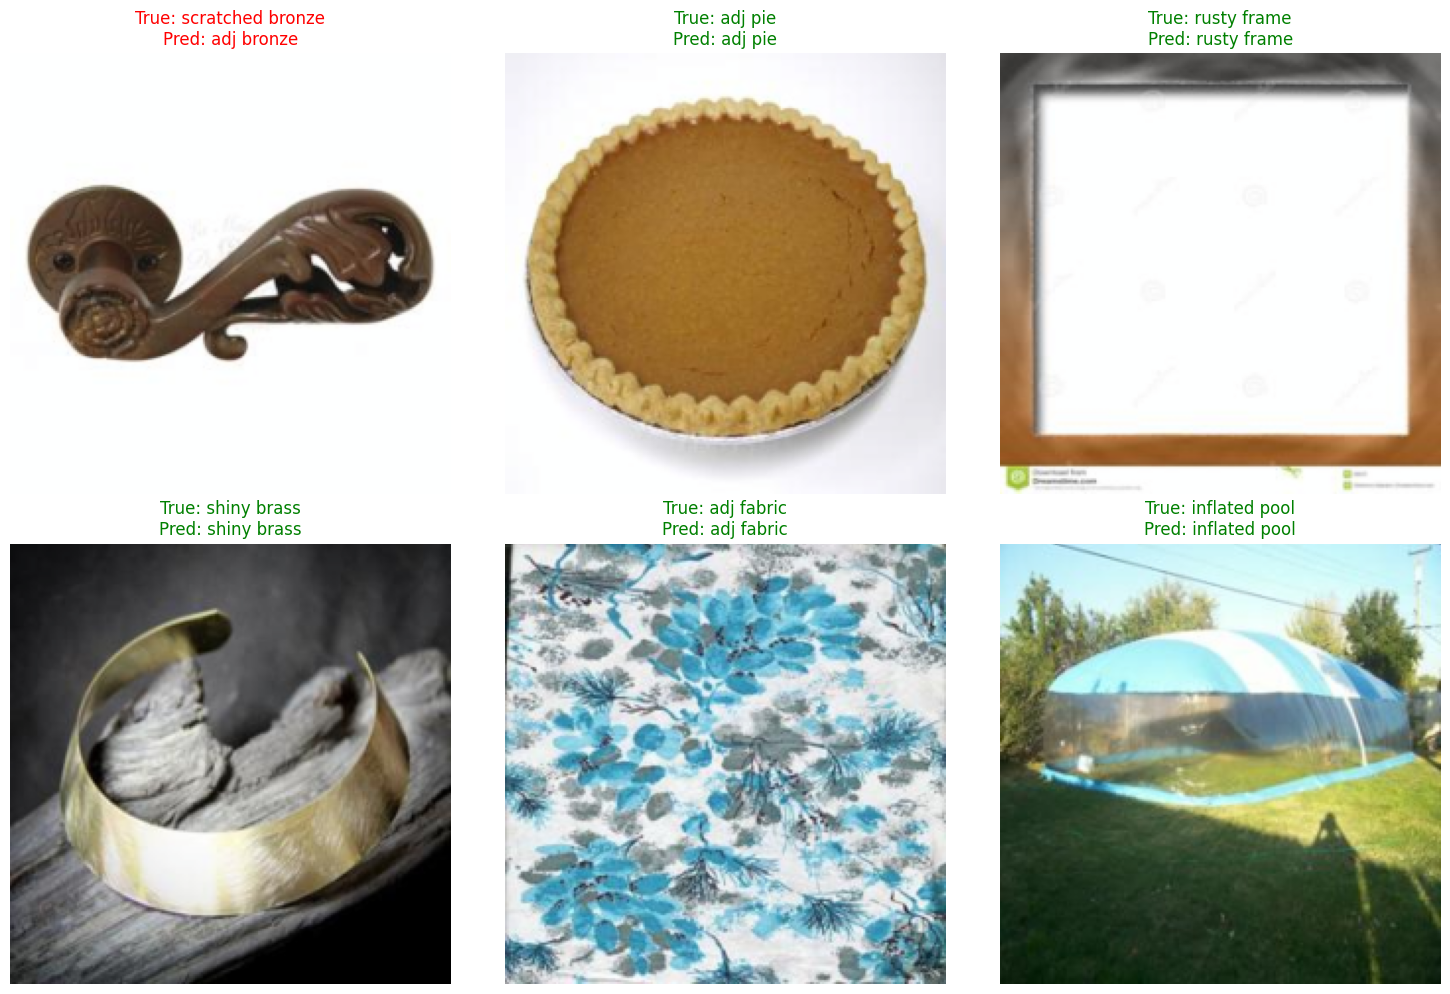

In [11]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, dataset, knowledge_matrix, num_images=6):
    """
    Grabs a batch from the dataloader, runs joint inference, and plots the 
    images with their True vs. Predicted labels.
    """
    # 1. Create reverse lookup dictionaries (Index -> String)
    idx2state = {v: k for k, v in dataset.state2idx.items()}
    idx2object = {v: k for k, v in dataset.object2idx.items()}
    
    # 2. Fetch a single batch of data
    images, true_states, true_objects = next(iter(dataloader))
    
    # 3. Get predictions using the fusion logic
    pred_states, pred_objects = joint_inference(model, images, knowledge_matrix)
    
    # 4. Setup the matplotlib grid
    rows = (num_images + 2) // 3
    fig, axes = plt.subplots(rows, min(num_images, 3), figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(num_images):
        # Denormalize the image for display
        img = images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure values are between 0 and 1 for imshow
        
        # Construct the label strings
        true_label = f"{idx2state[true_states[i].item()]} {idx2object[true_objects[i].item()]}"
        pred_label = f"{idx2state[pred_states[i]]} {idx2object[pred_objects[i]]}"
        
        # Color the title green if exactly correct, red if incorrect
        title_color = "green" if true_label == pred_label else "red"
        
        # Plot
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color, fontsize=12)
        axes[i].axis('off')
        
    # Hide any unused subplots
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Execute the visualization
visualize_predictions(model, dataloader, dataset, real_knowledge_prior, num_images=6)